# VSPAERO pitch-trimmed polar example

このNotebookでは、OpenVSPで読み込んだ`.vsp3`モデルに対して`vsp_trimmed_sweep()`を実行し、迎角ごとに

$$
C_{My,\mathrm{tot}}=0
$$

となるエレベータ舵角を求めた滑空極を作成する。

処理の流れは次のとおりである。

1. G103Aの`.vsp3`モデルを読み込む。
2. `WingGeom`と既存の`ELEVATOR_GROUP`を確認する。
3. 少数の迎角についてpitch-trimmed polarを計算する。
4. エレベータ舵角、`CMytot`残差、反復回数、計算時間を確認する。
5. 未補正の滑空性能を表とグラフで確認する。
6. 必要な場合だけ`make_CDo_correction()`を適用する。
7. 結果をCSVとPNGへ保存する。

この計算は`.stab`線形空力モデルを使う`example_turn_trim.ipynb`とは異なり、各評価点でVSPAEROを直接実行する。そのため、OpenVSP Python環境とVSPAERO実行環境が必要であり、迎角点数とトリム評価回数に応じて計算時間が増える。

本Notebookでは、`vsp_trimmed_sweep()` を使って迎角ごとのピッチトリムを直接計算する。

## 1. importとリポジトリ位置

Notebookの実行場所から親ディレクトリを順に調べ、`src/AnalysisVSPAERO.py`を含むリポジトリルートを見つける。

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

start_dir = Path.cwd().resolve()
repo_root = next(
    (
        candidate
        for candidate in [start_dir, *start_dir.parents]
        if (candidate / "src" / "AnalysisVSPAERO.py").exists()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Could not find the repository root containing "
        "src/AnalysisVSPAERO.py."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import openvsp as vsp  # noqa: E402
from src.AnalysisVSPAERO import (  # noqa: E402
    make_CDo_correction,
    vsp_trimmed_sweep,
)

print("repo_root:", repo_root)
print("OpenVSP version:", vsp.GetVSPVersion())

repo_root: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP
OpenVSP version: OpenVSP 3.47.0


## 2. 入力モデルと解析条件

通常変更する条件をこのセルへまとめる。

最初から多数の迎角を指定すると、各迎角で複数回VSPAEROが実行される。exampleの既定値は3点だけとし、モデル、Control Surface、トリム収束を確認してから迎角列を増やす。

`mass`は質量`kg`である。公開APIでは互換性のため引数名が`Weight`のまま残っている。

In [ ]:
model_path = (
    repo_root
    / "examples"
    / "notebooks"
    / "trimmed_polar"
    / "G103A.vsp3"
)
output_dir = (
    repo_root
    / "examples"
    / "notebooks"
    / "results"
    / "trimmed_polar"
)
output_dir.mkdir(parents=True, exist_ok=True)

mass = 580.0
altitude = 0.0
dT = 0.0

# 最初は少数点でモデル設定とトリム収束を確認する。
# alpha_list = [2.0, 4.0, 6.0]

# 本格的なpolarを計算するときの例。
alpha_list = [
    -2.0, -1.5, -1.0, -0.5, 0.0, 0.5,
    1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0,
]

elevator_bounds = (-20.0, 20.0)
cmy_tolerance = 5.0e-4
max_trim_evaluations = 30
trim_step_deg = 1.0

# Noneは、読み込んだOpenVSPモデルまたはOpenVSP既定値を維持する。
analysis_method = None
ncpu = None
wake_num_iter = None
fixed_wake_flag = None
verbose = 1

# 抵抗補正はVSPAEROトリム計算とは別の後処理である。
apply_cdo_correction = False
cdo_correction = {
    "xTr": (0.5, 0.7),
    "CDpCL": 0.0016,
    "thickness": 0.19,
    "interference_factor": 1.14,
}

if not model_path.exists():
    raise FileNotFoundError(model_path)

input_summary = pd.Series(
    {
        "model_path": str(model_path),
        "output_dir": str(output_dir),
        "mass_kg": mass,
        "altitude_m": altitude,
        "dT_K": dT,
        "alpha_list_deg": alpha_list,
        "elevator_bounds_deg": elevator_bounds,
        "cmy_tolerance": cmy_tolerance,
        "max_trim_evaluations": max_trim_evaluations,
        "trim_step_deg": trim_step_deg,
        "ncpu": ncpu,
        "wake_num_iter": wake_num_iter,
        "fixed_wake_flag": fixed_wake_flag,
        "apply_cdo_correction": apply_cdo_correction,
    },
    name="value",
)
display(input_summary)

model_path              C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...
output_dir              C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...
mass_kg                                                             580.0
altitude_m                                                            0.0
dT_K                                                                  0.0
alpha_list_deg          [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2...
elevator_bounds_deg                                         (-20.0, 20.0)
cmy_tolerance                                                      0.0005
max_trim_evaluations                                                   30
trim_step_deg                                                         1.0
ncpu                                                                 None
wake_num_iter                                                        None
fixed_wake_flag                                                      None
apply_cdo_correction                  

## 3. OpenVSPモデルの読込と前提確認

`vsp_trimmed_sweep()`は、次のモデル構成を前提とする。

- `WingGeom`がちょうど1個存在する。
- `ELEVATOR_GROUP`がちょうど1個存在する。
- `ELEVATOR_GROUP`に有効なControl Surfaceが登録されている。
- `VSPAEROSettings`にエレベータの`DeflectionAngle`が存在する。

ここでは解析前にその状態を表示する。Control Surface Groupやgainを作り直す処理はNotebookへ追加しない。

In [3]:
vsp.ClearVSPModel()
vsp.Update()
vsp.ReadVSPFile(str(model_path))
vsp.Update()

wing_ids = list(vsp.FindGeomsWithName("WingGeom"))
if len(wing_ids) != 1:
    raise RuntimeError(
        "Pitch-trimmed polar requires exactly one WingGeom. "
        f"found={wing_ids}"
    )

control_group_names = [
    vsp.GetVSPAEROControlGroupName(group_index)
    for group_index in range(vsp.GetNumControlSurfaceGroups())
]
elevator_group_indices = [
    group_index
    for group_index, group_name in enumerate(control_group_names)
    if group_name == "ELEVATOR_GROUP"
]
if len(elevator_group_indices) != 1:
    raise RuntimeError(
        "Pitch trim requires exactly one existing ELEVATOR_GROUP. "
        f"found={len(elevator_group_indices)}"
    )

elevator_group_index = elevator_group_indices[0]
active_elevator_surfaces = list(
    vsp.GetActiveCSNameVec(elevator_group_index)
)
if not active_elevator_surfaces:
    raise RuntimeError("ELEVATOR_GROUP has no active control surfaces.")

settings_id = vsp.FindContainer("VSPAEROSettings", 0)
if not settings_id:
    raise RuntimeError("VSPAEROSettings container was not found.")

elevator_parm_id = vsp.FindParm(
    settings_id,
    "DeflectionAngle",
    f"ControlSurfaceGroup_{elevator_group_index}",
)
if not elevator_parm_id or str(elevator_parm_id).upper() == "NONE":
    raise RuntimeError(
        "Could not find DeflectionAngle for ELEVATOR_GROUP."
    )

compgeom_name = "VSPAEROComputeGeometry"
vsp.SetAnalysisInputDefaults(compgeom_name)
compgeom_inputs = set(vsp.GetAnalysisInputNames(compgeom_name))
thick_geom_set = (
    int(vsp.GetIntAnalysisInput(compgeom_name, "GeomSet")[0])
    if "GeomSet" in compgeom_inputs
    else None
)
thin_geom_set = (
    int(vsp.GetIntAnalysisInput(compgeom_name, "ThinGeomSet")[0])
    if "ThinGeomSet" in compgeom_inputs
    else None
)

model_summary = pd.Series(
    {
        "vsp3_path": vsp.GetVSPFileName(),
        "wing_id": wing_ids[0],
        "control_group_names": control_group_names,
        "elevator_group_index": elevator_group_index,
        "active_elevator_surfaces": active_elevator_surfaces,
        "initial_elevator_deg": float(vsp.GetParmVal(elevator_parm_id)),
        "compute_geometry_GeomSet": thick_geom_set,
        "compute_geometry_ThinGeomSet": thin_geom_set,
    },
    name="value",
)
display(model_summary)

vsp3_path                       C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...
wing_id                                                                FJECIMNCTU
control_group_names                 [AILERON_GROUP, ELEVATOR_GROUP, RUDDER_GROUP]
elevator_group_index                                                            1
active_elevator_surfaces        [HTailGeom_Surf0_ELEVATOR, HTailGeom_Surf1_ELE...
initial_elevator_deg                                                          0.0
compute_geometry_GeomSet                                                        3
compute_geometry_ThinGeomSet                                                    4
Name: value, dtype: object

## 4. pitch-trimmed polarの計算

各迎角について、最初に揚力係数から飛行速度、Mach数、Reynolds数を求め、その条件でエレベータ舵角を変化させる。

受理条件は、

$$
\left|C_{My,\mathrm{tot}}\right|
\leq
\texttt{cmy\_tolerance}
$$

である。

前の迎角で得たエレベータ舵角と局所勾配を次の迎角の初期値として引き継ぐため、通常は後続caseほど少ない評価回数で収束する。

In [4]:
trimmed_polar = vsp_trimmed_sweep(
    vsp=vsp,
    alpha_list=alpha_list,
    Weight=mass,
    altitude=altitude,
    dT=dT,
    elevator_bounds=elevator_bounds,
    cmy_tolerance=cmy_tolerance,
    max_trim_evaluations=max_trim_evaluations,
    trim_step_deg=trim_step_deg,
    analysis_method=analysis_method,
    ncpu=ncpu,
    wake_num_iter=wake_num_iter,
    fixed_wake_flag=fixed_wake_flag,
    verbose=verbose,
)

# 後段の抵抗補正が元DataFrameを書き換えないよう、未補正結果を保持する。
trimmed_polar_raw = trimmed_polar.copy()

print("rows:", len(trimmed_polar_raw))
print("columns:")
print(", ".join(trimmed_polar_raw.columns))
display(trimmed_polar_raw.head())


-> VSPAERO trimmed sweep
 Geometry ready : C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\models\G103A\G103A.vspgeom (0.66 s)
 Cases          : 15
 VSPAERO run    : NCPU=4, WakeNumIter=5, FixedWakeFlag=False
 [  1/15] alpha=-2 deg
trim: ***
   complete: elevator=0.308051 deg, CMytot=-2.319e-06, dCMy/dde=-0.0263 1/deg, evaluations=3, V=61.8225, Mach=0.181675, Re=4.21703e+06
 [  2/15] alpha=-1.5 deg
trim: **
   complete: elevator=0.0173764 deg, CMytot=-7.505e-06, dCMy/dde=-0.0262741 1/deg, evaluations=2, V=52.7892, Mach=0.155129, Re=3.60085e+06
 [  3/15] alpha=-1 deg
trim: **
   complete: elevator=-0.282364 deg, CMytot=2.077e-06, dCMy/dde=-0.0262811 1/deg, evaluations=2, V=46.8421, Mach=0.137653, Re=3.19519e+06
 [  4/15] alpha=-0.5 deg
trim: **
   complete: elevator=-0.583775 deg, CMytot=1.203e-06, dCMy/dde=-0.0262851 1/deg, evaluations=2, V=42.5482, Mach=0.125034, Re=2.9023e+06
 [  5/15] alpha=0 deg
trim: **
   complete: elevator=-0.897936 deg, CMytot=1.414e-05, dCMy/dde=-0.02

,InputAlpha_deg,InputMach,InputReCref,Elevator_deg,CMyResidual,CMyElevatorSlope_per_deg,TrimFunctionEvaluations,NCPU,WakeNumIter,FixedWakeFlag,...,Mach,Re_1e6,StallFactor,CL,CMy,de,gamma,Velocity,Vx,vz
0,-2.0,0.181675,4.217033e+06,0.308051,-0.000002,-0.026300,3,4,5,False,...,0.181675,4.21703,1.0,0.139544,-0.000002,0.308051,0.068597,61.075803,219.355787,4.186310
1,-1.5,0.155129,3.600854e+06,0.017376,-0.000008,-0.026274,2,4,5,False,...,0.155129,3.60085,1.0,0.188339,-0.000008,0.017376,0.053249,52.547346,188.902312,2.796786
2,-1.0,0.137653,3.195191e+06,-0.282364,0.000002,-0.026281,2,4,5,False,...,0.137653,3.19519,1.0,0.236945,0.000002,-0.282364,0.044775,46.838962,168.451266,2.096509
3,-0.5,0.125034,2.902297e+06,-0.583775,0.000001,-0.026285,2,4,5,False,...,0.125034,2.90230,1.0,0.285387,0.000001,-0.583775,0.039757,42.674407,153.506469,1.696144
4,0.0,0.115382,2.678251e+06,-0.897936,0.000014,-0.026330,2,4,5,False,...,0.115382,2.67825,1.0,0.333613,0.000014,-0.897936,0.036475,39.467172,141.987312,1.439258


## 5. トリム収束の確認

空力係数そのものだけでなく、次を迎角ごとに確認する。

- `Elevator_deg`：受理されたエレベータ舵角
- `CMyResidual`：受理点の`CMytot`
- `CMyElevatorSlope_per_deg`：局所的なエレベータ有効度
- `TrimFunctionEvaluations`：その迎角でのトリム評価回数
- `SpeedConditionDuration_s`：速度条件を決める初回解析時間
- `TrimDuration_s`：エレベータトリムに使った解析時間の合計

In [5]:
diagnostic_columns = [
    "InputAlpha_deg",
    "Elevator_deg",
    "CMyResidual",
    "CMyElevatorSlope_per_deg",
    "TrimFunctionEvaluations",
    "SpeedConditionDuration_s",
    "TrimDuration_s",
    "InputMach",
    "InputReCref",
]

display(trimmed_polar_raw[diagnostic_columns])

max_abs_cmy_residual = float(
    trimmed_polar_raw["CMyResidual"].abs().max()
)
min_elevator_deg = float(trimmed_polar_raw["Elevator_deg"].min())
max_elevator_deg = float(trimmed_polar_raw["Elevator_deg"].max())

trim_summary = pd.Series(
    {
        "max_abs_CMyResidual": max_abs_cmy_residual,
        "cmy_tolerance": cmy_tolerance,
        "max_TrimFunctionEvaluations": int(
            trimmed_polar_raw["TrimFunctionEvaluations"].max()
        ),
        "total_TrimFunctionEvaluations": int(
            trimmed_polar_raw["TrimFunctionEvaluations"].sum()
        ),
        "min_Elevator_deg": min_elevator_deg,
        "max_Elevator_deg": max_elevator_deg,
        "total_SpeedConditionDuration_s": float(
            trimmed_polar_raw["SpeedConditionDuration_s"].sum()
        ),
        "total_TrimDuration_s": float(
            trimmed_polar_raw["TrimDuration_s"].sum()
        ),
    },
    name="value",
)
display(trim_summary)

if max_abs_cmy_residual > cmy_tolerance:
    raise AssertionError(
        "An accepted polar row exceeds cmy_tolerance. "
        f"max_abs={max_abs_cmy_residual}, tolerance={cmy_tolerance}"
    )
if min_elevator_deg < elevator_bounds[0] or max_elevator_deg > elevator_bounds[1]:
    raise AssertionError(
        "An accepted elevator deflection lies outside elevator_bounds."
    )

,InputAlpha_deg,Elevator_deg,CMyResidual,CMyElevatorSlope_per_deg,TrimFunctionEvaluations,SpeedConditionDuration_s,TrimDuration_s,InputMach,InputReCref
0,-2.0,0.308051,-0.000002,-0.026300,3,41.994,128.502,0.181675,4.217033e+06
1,-1.5,0.017376,-0.000008,-0.026274,2,41.161,84.580,0.155129,3.600854e+06
2,-1.0,-0.282364,0.000002,-0.026281,2,45.186,81.850,0.137653,3.195191e+06
3,-0.5,-0.583775,0.000001,-0.026285,2,42.144,84.186,0.125034,2.902297e+06
4,0.0,-0.897936,0.000014,-0.026330,2,41.357,84.047,0.115382,2.678251e+06
5,0.5,-1.214501,0.000004,-0.026343,2,43.165,84.167,0.107688,2.499651e+06
6,1.0,-1.538338,0.000011,-0.026378,2,44.401,87.739,0.101362,2.352827e+06
7,1.5,-1.866369,0.000006,-0.026396,2,42.133,88.707,0.096059,2.229727e+06
8,2.0,-2.196449,0.000014,-0.026437,2,43.018,88.146,0.091519,2.124345e+06
9,3.0,-2.865775,0.000045,-0.026505,2,41.316,87.397,0.084130,1.952814e+06


max_abs_CMyResidual                  0.000247
cmy_tolerance                        0.000500
max_TrimFunctionEvaluations          3.000000
total_TrimFunctionEvaluations       31.000000
min_Elevator_deg                    -9.944249
max_Elevator_deg                     0.308051
total_SpeedConditionDuration_s     637.574000
total_TrimDuration_s              1322.122000
Name: value, dtype: float64

## 6. 未補正polarの確認

`vsp_trimmed_sweep()`が返した未補正結果を確認する。

`Velocity`は`m/s`、`Vx`は`km/h`、`vz`は`m/s`である。`vz`は沈下速度の大きさとして正値で出力される。

In [6]:
polar_columns = [
    "InputAlpha_deg",
    "Elevator_deg",
    "CL",
    "CDi",
    "CDtot",
    "L_D",
    "Velocity",
    "Vx",
    "vz",
]
available_polar_columns = [
    column
    for column in polar_columns
    if column in trimmed_polar_raw.columns
]

display(trimmed_polar_raw[available_polar_columns])

performance_summary = pd.Series(
    {
        "max_L_D": float(trimmed_polar_raw["L_D"].max()),
        "alpha_at_max_L_D_deg": float(
            trimmed_polar_raw.loc[
                trimmed_polar_raw["L_D"].idxmax(),
                "InputAlpha_deg",
            ]
        ),
        "min_sink_speed_mps": float(trimmed_polar_raw["vz"].min()),
        "Vx_at_min_sink_kmh": float(
            trimmed_polar_raw.loc[
                trimmed_polar_raw["vz"].idxmin(),
                "Vx",
            ]
        ),
    },
    name="value",
)
display(performance_summary)

,InputAlpha_deg,Elevator_deg,CL,CDi,CDtot,L_D,Velocity,Vx,vz
0,-2.0,0.308051,0.139544,0.001528,0.009587,14.555101,61.075803,219.355787,4.186310
1,-1.5,0.017376,0.188339,0.001696,0.010038,18.761847,52.547346,188.902312,2.796786
2,-1.0,-0.282364,0.236945,0.002000,0.010616,22.319019,46.838962,168.451266,2.096509
3,-0.5,-0.583775,0.285387,0.002458,0.011352,25.139785,42.674407,153.506469,1.696144
4,0.0,-0.897936,0.333613,0.002991,0.012174,27.403639,39.467172,141.987312,1.439258
5,0.5,-1.214501,0.381645,0.003518,0.013006,29.342664,36.898536,132.757655,1.256775
6,1.0,-1.538338,0.429535,0.003958,0.013770,31.192752,34.779653,125.142457,1.114419
7,1.5,-1.866369,0.477165,0.004567,0.014724,32.407544,32.997550,118.734667,1.017721
8,2.0,-2.196449,0.524686,0.005288,0.015812,33.183815,31.467452,113.231424,0.947847
9,3.0,-2.865775,0.619108,0.007378,0.018704,33.100524,28.968679,104.239686,0.874774


max_L_D                 33.425645
alpha_at_max_L_D_deg     4.000000
min_sink_speed_mps       0.645532
Vx_at_min_sink_kmh      68.591436
Name: value, dtype: float64

## 7. トリム診断と滑空極のグラフ

図は一つずつ独立して作成し、Notebook表示と同時にPNGへ保存する。

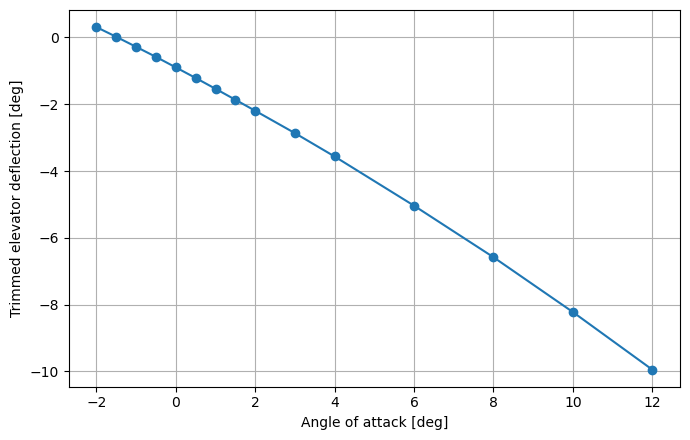

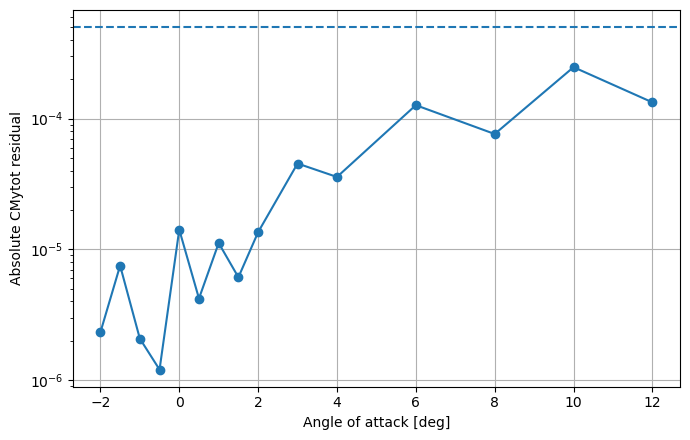

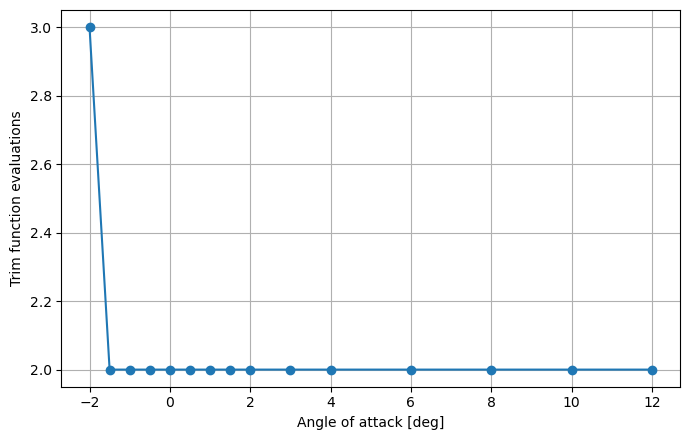

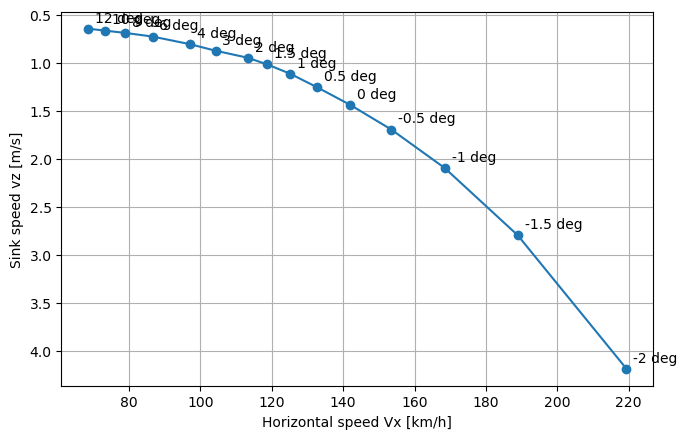

C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\trimmed_polar\trimmed_elevator_vs_alpha.png
C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\trimmed_polar\cmy_residual_vs_alpha.png
C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\trimmed_polar\trim_evaluations_vs_alpha.png
C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\trimmed_polar\uncorrected_glide_polar.png


In [7]:
figure_paths = []

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(
    trimmed_polar_raw["InputAlpha_deg"],
    trimmed_polar_raw["Elevator_deg"],
    marker="o",
)
ax.set_xlabel("Angle of attack [deg]")
ax.set_ylabel("Trimmed elevator deflection [deg]")
ax.grid(True)
fig.tight_layout()
path = output_dir / "trimmed_elevator_vs_alpha.png"
fig.savefig(path, dpi=150)
figure_paths.append(path)
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.semilogy(
    trimmed_polar_raw["InputAlpha_deg"],
    np.maximum(
        trimmed_polar_raw["CMyResidual"].abs(),
        np.finfo(float).tiny,
    ),
    marker="o",
)
ax.axhline(cmy_tolerance, linestyle="--")
ax.set_xlabel("Angle of attack [deg]")
ax.set_ylabel("Absolute CMytot residual")
ax.grid(True)
fig.tight_layout()
path = output_dir / "cmy_residual_vs_alpha.png"
fig.savefig(path, dpi=150)
figure_paths.append(path)
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(
    trimmed_polar_raw["InputAlpha_deg"],
    trimmed_polar_raw["TrimFunctionEvaluations"],
    marker="o",
)
ax.set_xlabel("Angle of attack [deg]")
ax.set_ylabel("Trim function evaluations")
ax.grid(True)
fig.tight_layout()
path = output_dir / "trim_evaluations_vs_alpha.png"
fig.savefig(path, dpi=150)
figure_paths.append(path)
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(
    trimmed_polar_raw["Vx"],
    trimmed_polar_raw["vz"],
    marker="o",
)
for row in trimmed_polar_raw.itertuples(index=False):
    ax.annotate(
        f"{row.InputAlpha_deg:g} deg",
        (row.Vx, row.vz),
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_xlabel("Horizontal speed Vx [km/h]")
ax.set_ylabel("Sink speed vz [m/s]")
ax.invert_yaxis()
ax.grid(True)
fig.tight_layout()
path = output_dir / "uncorrected_glide_polar.png"
fig.savefig(path, dpi=150)
figure_paths.append(path)
plt.show()

for path in figure_paths:
    print(path)

## 8. 任意のCDo補正

`make_CDo_correction()`は、VSPAEROのpitch trimとは別の後処理である。`apply_cdo_correction=True`にした場合だけ、未補正DataFrameのコピーへ適用する。

補正値`xTr`、`CDpCL`、`thickness`、`interference_factor`は対象機に対する仮定であり、VSPAEROが自動的に決定する値ではない。

In [8]:
corrected_polar = None

if apply_cdo_correction:
    corrected_polar = make_CDo_correction(
        vsp,
        trimmed_polar_raw.copy(),
        Weight=mass,
        altitude=altitude,
        dT=dT,
        **cdo_correction,
    )

    corrected_columns = [
        "InputAlpha_deg",
        "Elevator_deg",
        "CL",
        "CDi",
        "CDo_corr",
        "CDtot_corr",
        "L_D_corr",
        "Velocity",
        "Vx",
        "vz",
    ]
    display(corrected_polar[corrected_columns])

    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(
        trimmed_polar_raw["Vx"],
        trimmed_polar_raw["vz"],
        marker="o",
        label="VSPAERO uncorrected",
    )
    ax.plot(
        corrected_polar["Vx"],
        corrected_polar["vz"],
        marker="o",
        label="CDo corrected",
    )
    ax.set_xlabel("Horizontal speed Vx [km/h]")
    ax.set_ylabel("Sink speed vz [m/s]")
    ax.invert_yaxis()
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    corrected_plot_path = output_dir / "corrected_glide_polar.png"
    fig.savefig(corrected_plot_path, dpi=150)
    plt.show()
    print(corrected_plot_path)
else:
    print(
        "CDo correction was not applied. "
        "Set apply_cdo_correction=True and rerun from section 2 "
        "when the correction assumptions are intended."
    )

CDo correction was not applied. Set apply_cdo_correction=True and rerun from section 2 when the correction assumptions are intended.


## 9. CSV出力

未補正polarは必ず保存する。CDo補正を実行した場合だけ、補正後polarを別ファイルへ保存する。

In [9]:
raw_csv_path = output_dir / "G103A_trimmed_polar_raw.csv"
trimmed_polar_raw.to_csv(raw_csv_path, index=False)
print("raw_csv_path:", raw_csv_path)

corrected_csv_path = None
if corrected_polar is not None:
    corrected_csv_path = output_dir / "G103A_trimmed_polar_corrected.csv"
    corrected_polar.to_csv(corrected_csv_path, index=False)
    print("corrected_csv_path:", corrected_csv_path)

raw_csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\trimmed_polar\G103A_trimmed_polar_raw.csv


## 10. 確認事項

- OpenVSP Python環境とVSPAERO実行環境が利用可能であること。
- 読み込んだモデルに`WingGeom`がちょうど1個存在すること。
- `ELEVATOR_GROUP`がちょうど1個存在し、有効なControl Surfaceを持つこと。
- `VSPAEROComputeGeometry`のThick/Thin geometry setが対象モデルの意図どおりであること。
- 全caseで`abs(CMyResidual) <= cmy_tolerance`となっていること。
- `Elevator_deg`が`elevator_bounds`の端へ張り付いていないこと。
- `CMyElevatorSlope_per_deg`の符号と大きさが迎角間で不自然に急変していないこと。
- 後続caseで`TrimFunctionEvaluations`が減るか、少なくとも過度に増加していないこと。
- `CL > 0`であり、`Velocity`、`L_D`、`Vx`、`vz`が有限値であること。
- 未補正結果と経験的なCDo補正後の結果を混同しないこと。
- 迎角列を増やす前に、少数点で計算時間とwake収束設定を確認すること。
- `vsp_trimmed_sweep()`終了後に、モデルの元のエレベータ舵角へ復元されていること。